# Clase 3: Python Científico (NumPy, Pandas, Matplotlib & Seaborn)



## Objetivos de hoy
1. Manipular arreglos numéricos eficientes con NumPy.
2. Crear visualizaciones básicas con Matplotlib y Seaborn.
3. Operaciones vectorizadas.
4. Integración de procesos previos con el análisis y visualización
    


## Introducción General
El análisis de datos en la astrofísica y ciencias modernas no se hace con ciclos `for` en Python puro; sería prohibitivamente lento. En su lugar, utilizamos un "stack" de librerías altamente optimizadas.
* **NumPy:** Es el motor matemático. Maneja arreglos de datos en C y Fortran de forma invisible para una velocidad extrema.
* **Pandas:** Es el "Excel" con superpoderes. Maneja datos tabulares, catálogos y series temporales.
* **Matplotlib:** Es el lienzo fundamental para dibujar cualquier tipo de gráfica científica.
* **Seaborn:** Es el pincel elegante. Basado en Matplotlib, permite hacer gráficos estadísticos complejos con muy poco código.

## **1. NumPy: Computación Numérica de Alto Rendimiento**

NumPy (Numerical Python) introduce el objeto `ndarray` (arreglo n-dimensional). A diferencia de las listas de Python, un `ndarray` ocupa un bloque contiguo en la memoria RAM, permitiendo aplicar matemáticas a millones de datos de golpe sin usar bucles. A esto se le llama **Vectorización**.

### Herramientas más importantes:
* `np.array()`: Crear arreglos.
* `np.linspace()` / `np.arange()`: Crear secuencias numéricas.
* `np.where()`: Lógica condicional vectorizada.
* Operadores booleanos (máscaras) para filtrado rápido.

### ¿Cuándo usarlo?
Cuando tienes matrices de datos numéricos crudos (como los píxeles de una imagen FITS astronómica o simulaciones de N-cuerpos) y necesitas aplicarles ecuaciones físicas.




### Ejemplo 1: Conversión de Unidades

In [1]:
import numpy as np

# Supongamos que tenemos distancias estelares en parsecs (pc)
distancias_pc = np.array([1.3, 5.0, 12.4, 20.1, 100.5])

# Queremos convertirlas a años luz. En lugar de un 'for', multiplicamos todo el array
distancias_ly = distancias_pc * 3.26156

print("Distancias en Años Luz:", distancias_ly)

Distancias en Años Luz: [  4.240028  16.3078    40.443344  65.557356 327.78678 ]


### Ejemplo 2: Máscaras Booleanas Complejas e Indexación Numérica
Encontrar estrellas en la "Secuencia Principal" basándonos en parámetros de temperatura ($T_{eff}$) y gravedad superficial ($log_{10}(g)$).

In [2]:
import numpy as np

np.random.seed(42)
# Generamos 100,000 estrellas simuladas
teff = np.random.uniform(3000, 10000, 100000)
logg = np.random.uniform(0.5, 5.5, 100000)

# Condición física de Secuencia Principal (aprox): T < 8000K y log(g) > 4.0
# Usamos el operador '&' (AND de bit a bit), no 'and' de Python
mascara_ms = (teff < 8000) & (logg > 4.0)

# Extraemos solo las estrellas que cumplen la condición
estrellas_ms_teff = teff[mascara_ms]
estrellas_ms_logg = logg[mascara_ms]

print(f"Población original: {len(teff)} estrellas.")
print(f"Estrellas en Secuencia Principal: {len(estrellas_ms_teff)}.")

Población original: 100000 estrellas.
Estrellas en Secuencia Principal: 21638.


## **Pandas: Minería de Datos Tabulares**
Pandas está diseñado para limpiar, cruzar y analizar tablas (como los catálogos `.csv` que descargaste la semana pasada con `wget`). Sus objetos principales son la Series (1 dimensión, una columna) y el DataFrame (2 dimensiones, una tabla).

Herramientas más importantes:
* `pd.read_csv()`: Leer archivos.
* `df.dropna()`, `df.fillna()`: Control de calidad, manejar datos faltantes (NaN).
* `df.groupby()`: Agrupación estadística (similar al GROUP BY de SQL).
* `df.merge()`: Cruzar dos catálogos diferentes por un ID común.

**¿Cuándo usarlo?**

Siempre que tengas un archivo tabular (CSV, TSV, Excel, bases de datos SQL) donde las columnas tengan diferentes tipos de datos (texto, números, fechas). Es el rey de la "Limpieza de Datos" (Data Wrangling).

### Ejemplo 3: Carga y Exploración
Simulamos un diccionario para crear un DataFrame

In [3]:
import pandas as pd

datos = {
    'Objeto': ['M31', 'M33', 'NGC104', 'NGC6752'],
    'Tipo': ['Galaxia', 'Galaxia', 'Cúmulo', 'Cúmulo'],
    'Distancia_kpc': [780, 850, 4.5, 4.0],
    'Masa_Msol': [1e12, 5e10, np.nan, 2e5] # Notemos un dato faltante (NaN)
}
df = pd.DataFrame(datos)

print('El DF completo es:\n', df)
print('\n'+'-'*10+'\n')
print('El DF filtrado es:')
# Filtrar solo galaxias
galaxias = df[df['Tipo'] == 'Galaxia']
print(galaxias)

El DF completo es:
     Objeto     Tipo  Distancia_kpc     Masa_Msol
0      M31  Galaxia          780.0  1.000000e+12
1      M33  Galaxia          850.0  5.000000e+10
2   NGC104   Cúmulo            4.5           NaN
3  NGC6752   Cúmulo            4.0  2.000000e+05

----------

El DF filtrado es:
  Objeto     Tipo  Distancia_kpc     Masa_Msol
0    M31  Galaxia          780.0  1.000000e+12
1    M33  Galaxia          850.0  5.000000e+10


### Ejemplo 4: Agrupación y Limpieza (Data Quality)
Rellenar la masa faltante con la media de su propio 'Tipo' (Cúmulo)

In [4]:
df['Masa_Msol'] = df['Masa_Msol'].fillna(df.groupby('Tipo')['Masa_Msol'].transform('mean'))

# Calcular la masa total por tipo de objeto
masa_total = df.groupby('Tipo')['Masa_Msol'].sum().reset_index()
print("\nMasa Total Agrupada:\n", masa_total)


Masa Total Agrupada:
       Tipo     Masa_Msol
0   Cúmulo  4.000000e+05
1  Galaxia  1.050000e+12


## **Matplotlib: El Lienzo de la Visualización**
Matplotlib es la columna vertebral gráfica de Python. Tiene dos enfoques: el estilo "MATLAB" (`plt.plot()`) que es rápido para cosas simples, y el estilo Orientado a Objetos (`fig, ax = plt.subplots()`), que es obligatorio para crear figuras científicas complejas.

Herramientas más importantes:
* `plt.subplots()`: Crea la figura (el lienzo) y los ejes (los paneles).
* `ax.scatter()`, `ax.plot()`, `ax.hist()`: Tipos de gráficos.
* `ax.set_xlabel()`, `ax.set_ylabel()`: Etiquetado, vital en ciencia.
* `plt.savefig()`: Exportar para tu paper.

¿Cuándo usarlo?

Para tener un control milimétrico sobre cada píxel del gráfico: cambiar el grosor de las líneas, mover leyendas, crear figuras con múltiples sub-paneles y ajustar escalas logarítmicas.

### Ejemplo 5: Gráfico de Dispersión simple

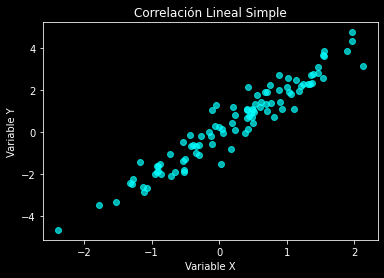

In [5]:
import matplotlib.pyplot as plt

# Usar estilo oscuro (muy usado en astronomía)
plt.style.use('dark_background')

x = np.random.normal(0, 1, 100)
y = x * 2 + np.random.normal(0, 0.5, 100)

plt.scatter(x, y, color='cyan', alpha=0.7)
plt.title("Correlación Lineal Simple")
plt.xlabel("Variable X")
plt.ylabel("Variable Y")
plt.show()

### Ejemplo 6. Histogramas y Estadística
Supongamos que tenemos datos de magnitudes de estrellas (distribución normal simulada).


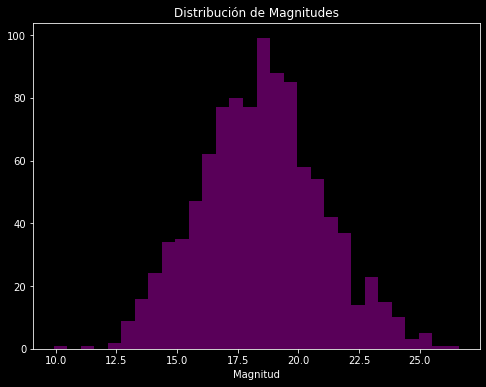

In [6]:
import numpy as np
import matplotlib.pyplot as plt
magnitudes = np.random.normal(loc=18.5, scale=2.5, size=1000)

plt.figure(figsize=(8, 6))
plt.hist(magnitudes, bins=30, color='purple', alpha=0.7)
plt.title("Distribución de Magnitudes")
plt.xlabel("Magnitud")
plt.show()


### Ejemplo 7: Ejes Múltiples y Escalas (Diagrama H-R)

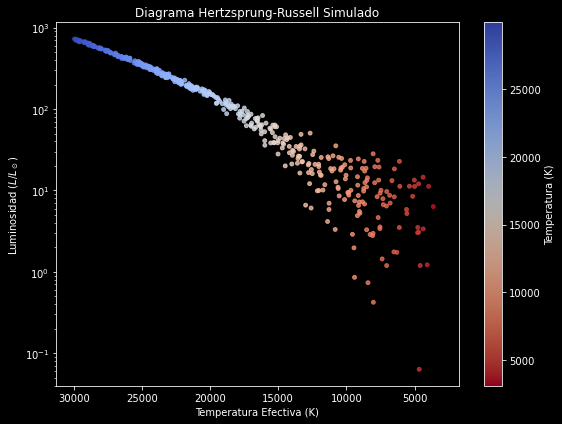

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

# Datos simulados de un Cúmulo (Temperatura vs Luminosidad)
temp = np.random.uniform(3000, 30000, 500)
# Relación L ~ T^4 con ruido
lum = (temp/5778)**4 + np.random.normal(0, 10, 500)

# El color del punto dependerá de la temperatura (caliente=azul, frío=rojo)
scatter = ax.scatter(temp, lum, c=temp, cmap='coolwarm_r', s=15, alpha=0.8)

# Configuración Astronómica Crítica:
ax.set_yscale('log') # Luminosidad en escala logarítmica
ax.invert_xaxis()    # En astronomía, la temperatura disminuye hacia la derecha!

ax.set_xlabel("Temperatura Efectiva (K)")
ax.set_ylabel("Luminosidad ($L/L_\odot$)")
ax.set_title("Diagrama Hertzsprung-Russell Simulado")

# Añadir barra de color
cbar = plt.colorbar(scatter)
cbar.set_label("Temperatura (K)")

plt.tight_layout()
plt.show()

## **Seaborn: Visualización Estadística Elegante**
Seaborn envuelve a Matplotlib y a Pandas. Mientras que en Matplotlib debes configurar colores y bucles para agrupar datos, Seaborn entiende los DataFrames de Pandas de forma nativa e infiere cómo mapear columnas a colores o estilos automáticamente.

Herramientas más importantes:
* `sns.scatterplot(data=df, x='col1', y='col2', hue='categoría')`
* `sns.histplot()`: Histogramas con curvas de densidad (KDE).
* `sns.pairplot()`: Matriz de correlación instantánea para todas las variables numéricas.
* `sns.violinplot()`, `sns.boxplot()`: Distribuciones.

¿Cuándo usarlo?

Durante el Análisis Exploratorio de Datos (EDA). Cuando tienes un catálogo de Pandas con múltiples características (masas, radios, periodos, métodos) y quieres ver rápidamente cómo se correlacionan o se distribuyen por categorías sin escribir código de configuración complejo.

### Ejemplo 8: Distribuciones (Violin Plot)
Simulado de exoplanetas

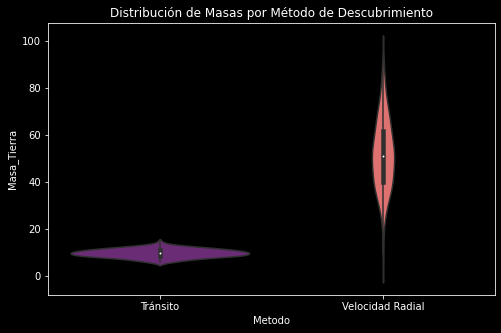

In [8]:
import seaborn as sns

metodos = ['Tránsito'] * 100 + ['Velocidad Radial'] * 100
masas = np.concatenate([np.random.normal(10, 2, 100), np.random.normal(50, 15, 100)])
df_exo = pd.DataFrame({'Metodo': metodos, 'Masa_Tierra': masas})

plt.figure(figsize=(8, 5))
# Un violin plot muestra la distribución de densidad para cada categoría
sns.violinplot(data=df_exo, x='Metodo', y='Masa_Tierra', palette='magma')
plt.title("Distribución de Masas por Método de Descubrimiento")
plt.show()

### Ejemplo 9: Pairplot (Relaciones Multivariables)
Simulamos un catálogo con múltiples propiedades correlacionadas

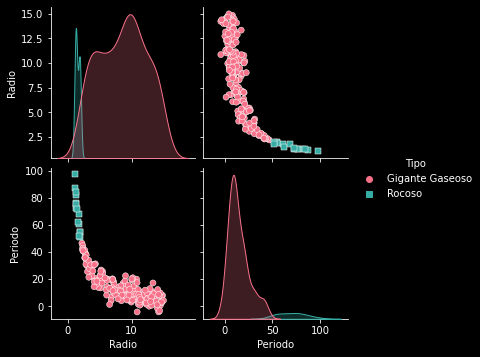

In [9]:
np.random.seed(0)
n = 200
radio = np.random.uniform(1, 15, n)
# Periodo más corto si el radio es más grande, con ruido
periodo = (100 / radio) + np.random.normal(0, 5, n)
# Clasificamos según el tamaño
tipo = ['Rocoso' if r < 2 else 'Gigante Gaseoso' for r in radio]

df_multi = pd.DataFrame({'Radio': radio, 'Periodo': periodo, 'Tipo': tipo})

# El Pairplot dibuja scatter plots entre todas las variables numéricas,
# coloreadas por la categoría ('Tipo').
# Es la herramienta más potente para encontrar correlaciones ocultas.
sns.pairplot(df_multi, hue='Tipo', palette='husl', markers=["o", "s"])
plt.show()

## Cheatsheet
Es importante saber de todos los posibles usos que tiene cada una de las herramientas, así que dejamos por acá unas cheatsheet para cada uno de las librerías con el fin de acceder de manera rápida y sencilla a sus funciones.

Cheatsheet para Numpy

![Cheatsheet Numpy](./imagenes/numpy-cheat-sheet.png)

Imagen tomada de: [Link](https://ashutoshtripathi.com/wp-content/uploads/2019/02/numpy-cheat-sheet.png)

Cheatsheet para Pandas

![Cheatsheet Pandas](./imagenes/pandas_cheatsheet.png)

Imagen tomada de: [Link](https://www.kaggle.com/discussions/getting-started/156692)

Cheatsheet para Matplotlib

![Cheatsheet Matplotlib](./imagenes/matplotlib_cheatsheets.png)

Imagen tomada de: [Link](https://matplotlib.org/cheatsheets/)

Cheatsheet para Seaborn

![Cheatsheet Seaborn](./imagenes/seaborn_cheatsheet.png)

Imagen tomada de: [Link](https://www.kaggle.com/discussions/getting-started/124992)



## Ejercicios de clase
A continuación se presentan un conjunto de ejercicios para ser desarrollados durante la clase.

### Ejercicio 1: Integración Numérica del Flujo

1. Crea un array tiempo de 0 a 10 segundos con 10,000 puntos usando np.linspace.
2. Modela una señal de un púlsar: `señal = np.sin(2 * np.pi * 5 * tiempo) * np.exp(-tiempo / 3)`. (Una onda de 5Hz con decaimiento exponencial).
3. Encuentra los instantes de tiempo donde la señal supera el umbral de 0.5 usando máscaras.
4. Calcula el "flujo total" (la suma acumulada) de la señal sólo durante esos instantes que superan el umbral.
Solución: `mascara = señal > 0.5; tiempos_altos = tiempo[mascara]`; `flujo_total = np.sum(señal[mascara])`.


In [10]:
# Escribe tu código bash aquí


### Ejercicio 2: Limpieza Extrema de Catálogos

1. Suponga un DataFrame df con las columnas [Objeto, $B_{mag}$, $V_{mag}$] con múltiples NaN en las magnitudes.
2. Crea una nueva columna llamada $Color_{BV}$ que sea la resta $B_{mag}$ - $V_{mag}$.
3. Pandas dejará como NaN el color si falta alguna magnitud. Elimina todas las filas (`dropna()`) que no tengan el índice de color calculado.
4. Encuentra cuál es el objeto con el índice de color más bajo (el más azul) usando el método df.loc[df[Color$_{BV}$].idxmin()].

In [11]:
# Escribe tu código bash aquí


### Ejercicio 3: El Panel Observacional

1. Usa `plt.subplots(2, 2)` para crear una figura de 2x2 (4 paneles).
2. En el panel (0,0) grafica una curva seno, en (0,1) un coseno.
3. En la fila inferior (paneles 1,0 y 1,1) grafica dos histogramas con distribuciones normales (`np.random.randn(1000)`), pero con diferentes "bins" (e.g., 10 y 50).
4. Asegúrate de añadir títulos individuales a cada "ax" (usando `ax[0,0].set_title(...)`) y llama a `plt.tight_layout()` al final para evitar que los textos se superpongan.

In [12]:
# Escribe tu código bash aquí


### Ejercicio 4: KDE Bivariado

1. Carga un dataset incluido en Seaborn, por ejemplo, los pinguinos: `df = sns.load_dataset("penguins")`.
2. Queremos ver la relación topológica entre el largo del pico (`bill_length_mm`) y la profundidad (`bill_depth_mm`).
3. En lugar de un gráfico de dispersión (Scatter), usa `sns.kdeplot()` pasando las dos columnas, y activa el parámetro `fill=True` (para crear contornos sombreados de probabilidad topográfica) y separa por especies usando `hue='species'`.

In [13]:
# Escribe tu código bash aquí


## Proyectos Integradores (Consola + GitHub + Análisis Científico)
**Modalidad**: Parejas (IP y Co-I). Ambos deben tener acceso a su terminal (Linux/WSL) para los comandos CLI/Git, y pueden usar scripts de Python locales o un Notebook local (no web) para el análisis gráfico.

### **Proyecto Integrador 1**: "Descubriendo la Estructura Galáctica"

Obtener datos de la misión Gaia desde el Observatorio Virtual usando CLI, limpiarlos, graficar la distribución de estrellas usando Seaborn/Matplotlib, y someter el código a revisión en GitHub.

1. Investigador Principal (IP):
* Crea un repositorio en GitHub (proyecto_estructura_galactica) e invita al Co-I.
* En su terminal local, el IP clona el repo.
* Usa CLI para bajar un extracto del catálogo de Gaia DR3 con astrometría de alta calidad.
```bash
wget -q -O gaia.csv "https://tapvizier.cds.unistra.fr/TAPVizieR/tap/sync?request=doQuery&lang=ADQL&format=csv&query=SELECT+TOP+50000+Source,RA_ICRS,DE_ICRS,Plx,e_Plx,Gmag+FROM+%22I/355/gaiadr3%22+WHERE+Plx)>5"
```
* Aplica Control de Calidad (DQ) desde Bash para remover cualquier error: `awk -F',' 'NR==1 || $4 != ""' gaia.csv > gaia_limpio.csv`.
* Añade `gaia.csv` al `.gitignore`. Hace commit de `gaia_limpio.csv` y hace `push` a la rama main.

2. Co-Investigador (Co-I):

* Clona el repositorio. Crea una rama `analisis_paralaje`.
* Crea un script de Python (`analisis.py` o un Jupyter Notebook) en el repositorio.
* Usa Pandas para cargar `gaia_limpio.csv`.
* Calcula la distancia en parsecs creando una nueva columna: `df['Distancia_pc'] = 1000 / df['Plx']`. (Asumiendo paralaje en milisegundos de arco).
* Usa Seaborn para crear un `sns.histplot` de la columna `Distancia_pc` con una curva `kde=True` para ver cómo se distribuyen las estrellas en nuestro vecindario galáctico.
* Guarda la figura, hace commit del código y de la figura, hace push a su rama, y abre un Pull Request.

3. Peer Review:

* El IP revisa el código de Python en el PR. Verifica que la división por cero no sea un problema (gracias a la limpieza inicial). Aprueba el PR (Merge).

In [14]:
# Escribe tu código bash aquí


### **Proyecto Integrador 2**: "El Zoológico de Exoplanetas"

Usar el API de NASA, limpiar datos de misiones exoplanetarias y utilizar diagramas de dispersión avanzados en Matplotlib para replicar un gráfico estándar de la industria (Masa vs Radio).

1. Investigador Principal (IP):

* Crea un repositorio en GitHub (`zoo_exoplanetario`) e invita al Co-I.
* En su terminal local, el IP clona el repo.
* Usa CLI para bajar el catálogo de sistemas planetarios de la NASA.

```bash
wget -q -O exoplanetas.csv "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=SELECT+pl_name,discoverymethod,pl_rade,pl_bmasse+FROM+ps&format=csv"
```

* Aplica DQ desde Bash para evitar que Pandas colapse por datos faltantes críticos. Vamos a requerir que los planetas tengan tanto Radio (columna 3) como Masa (columna 4).
* Añade `exoplanetas.csv` al `.gitignore`. Hace commit de exo_limpios.csv y push a main.

2. Co-Investigador (Co-I):

* Clona el repo. Crea una rama `analisis_masaradio`.
* Crea su entorno de trabajo de Python. Usa Pandas para cargar `exo_limpios.csv`.
* Usa Seaborn (`sns.scatterplot`) o Matplotlib para hacer un gráfico de Masa (eje X) vs Radio (eje Y).
* En escalas lineales, los exoplanetas gigantes aplastarán a los rocosos en una esquina. El Co-I debe usar escalas logarítmicas en Matplotlib (`plt.xscale('log')` y `plt.yscale('log')`).
* Usa el parámetro `hue='discoverymethod'` (si usa Seaborn) para colorear los puntos dependiendo de cómo fueron descubiertos (`Tránsito` vs `Velocidad Radial`).
* Guarda la figura, hace commit, push, y abre un Pull Request.

3. Peer Review:
* El IP revisa el PR. Se dará cuenta de que el gráfico log-log separa bellamente las poblaciones de planetas tipo Tierra, Neptunos y Júpiteres Calientes según su método de descubrimiento. Tras revisar el uso de la API de Matplotlib/Seaborn, aprueba el PR.

In [15]:
  # Escribe tu código bash aquí
